In [3]:
import cellxgene_census
import scanpy as sc

print("Connecting to CELLxGENE...")
with cellxgene_census.open_soma() as census:
    
    # 1. Get the metadata of cells matching colon cancer
    print("Finding colon cancer cell IDs...")
    cell_metadata = cellxgene_census.get_obs(
        census,
        organism="Homo sapiens",
        value_filter="tissue_general == 'large intestine' and disease == 'colon adenocarcinoma' and is_primary_data == True"
    )
    
    # 2. Take the first 5,000 matching cell IDs
    colon_cancer_ids = cell_metadata.soma_joinid.values[:5000].tolist()
    
    # 3. Pull the actual gene matrix for just those 5,000 cells
    print(f"Streaming gene matrices for {len(colon_cancer_ids)} cells...")
    adata = cellxgene_census.get_anndata(
        census=census,
        organism="Homo sapiens",
        obs_coords=colon_cancer_ids
    )

print("\n--- COLON CANCER DATASET SUCCESSFULLY LOADED ---")
print(adata)

Connecting to CELLxGENE...


The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


Finding colon cancer cell IDs...
Streaming gene matrices for 5000 cells...


/Users/bishtananya/miniconda3/envs/sc-env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/bishtananya/miniconda3/envs/sc-env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



--- COLON CANCER DATASET SUCCESSFULLY LOADED ---
AnnData object with n_obs × n_vars = 5000 × 61497
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'


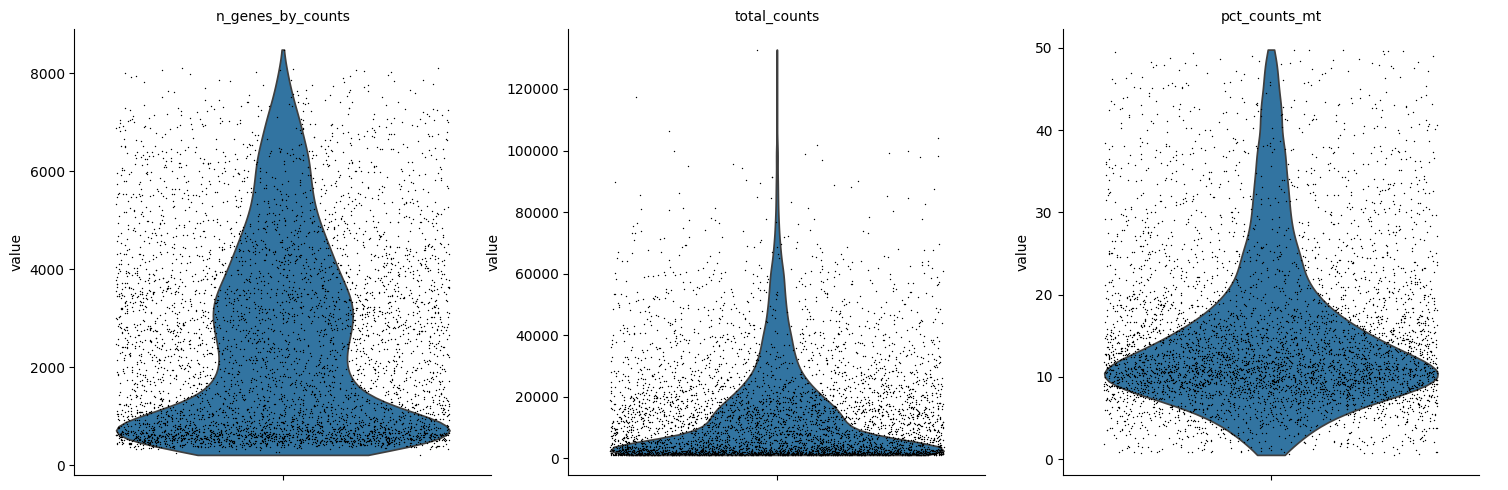

In [4]:
# 1. Identify mitochondrial genes (they all start with 'MT-' in human cells)
# We flag them in the 'var' data frame using their gene name
adata.var['mt'] = adata.var['feature_name'].str.startswith('MT-')

# 2. Calculate Scanpy's built-in QC metrics
# This automatically counts total molecules, total genes, and mitochondrial percentage per cell
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# 3. Plot the metrics using violin plots to visualize our thresholds
sc.pl.violin(
    adata, 
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], 
    jitter=0.4, 
    multi_panel=True
)

In [5]:
print(f"Cells before filtering: {adata.n_obs}")

# Apply our visual thresholds
# 1. Keep cells with less than 20% mitochondrial activity
adata = adata[adata.obs['pct_counts_mt'] < 20, :]

# 2. Keep cells with more than 500 genes but fewer than 6500 genes
adata = adata[(adata.obs['n_genes_by_counts'] > 500) & 
              (adata.obs['n_genes_by_counts'] < 6500), :]

print(f"Cells after filtering: {adata.n_obs}")

Cells before filtering: 5000
Cells after filtering: 3593


In [6]:
# 'donor_id' is the standardized metadata tracking the unique patient/donor
patient_counts = adata.obs['donor_id'].value_counts()

print("--- PATIENT BREAKDOWN IN YOUR DATASET ---")
print(patient_counts)
print(f"\nTotal unique patients: {adata.obs['donor_id'].nunique()}")

--- PATIENT BREAKDOWN IN YOUR DATASET ---
donor_id
C103    3593
Name: count, dtype: int64

Total unique patients: 1


In [7]:
# 1. Save the raw counts in a separate slot before we modify them
adata.raw = adata

# 2. Normalize every cell so they all sum up to exactly 10,000 molecules
# This makes a cell with 2,000 counts comparable to a cell with 8,000 counts
sc.pp.normalize_total(adata, target_sum=1e4)

# 3. Logarithmize the data (Converts skewed exponential counts to a linear scale)
# This prevents highly dominant genes from completely crushing subtle immune genes
sc.pp.log1p(adata)

print("Dataset successfully normalized and log-transformed!")

Dataset successfully normalized and log-transformed!


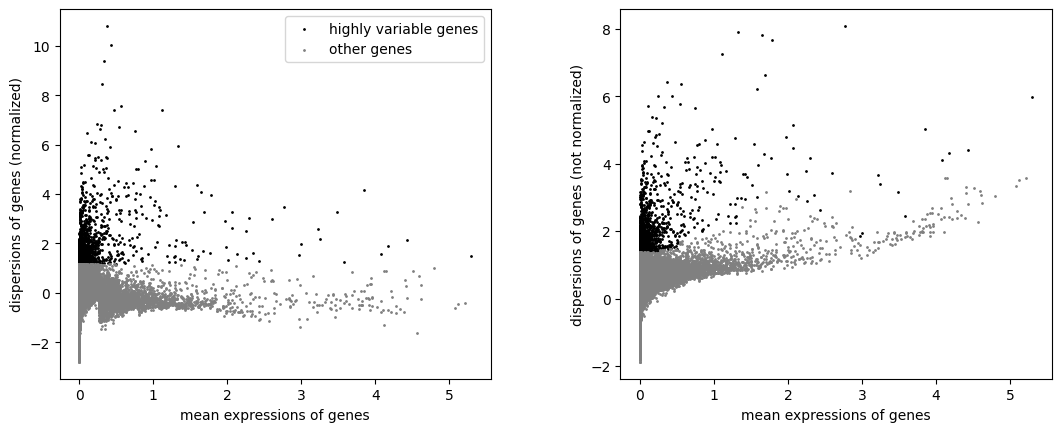

AttributeError: 'DataFrame' object has no attribute 'highly_variable_genes'

In [8]:
# 1. Identify the top 2,000 most variable genes in the dataset
# We use the 'seurat' flavor which is a standard, robust statistical method
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat')

# 2. Plot the variance so we can inspect the distribution visually
sc.pl.highly_variable_genes(adata)

# 3. Filter our dataset to keep ONLY these 2,000 important genes
# This reduces our matrix from 3593 × 61497 down to a lean 3593 × 2000
adata = adata[:, adata.var.highly_variable_genes]

print(f"Dataset dimensionality post-feature selection: {adata.shape}")

/Users/bishtananya/miniconda3/envs/sc-env/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: divide by zero encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/bishtananya/miniconda3/envs/sc-env/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: overflow encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/bishtananya/miniconda3/envs/sc-env/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: invalid value encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/bishtananya/miniconda3/envs/sc-env/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:737: RuntimeWarning: divide by zero encountered in matmul
  matmat=lambda x: X @ x - offset @ x,
/Users/bishtananya/miniconda3/envs/sc-env/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:737: RuntimeWarning: overflow encountered in matmul
  matmat=lambda x: X @ x - offset @ x,
/Users/bishtananya/miniconda

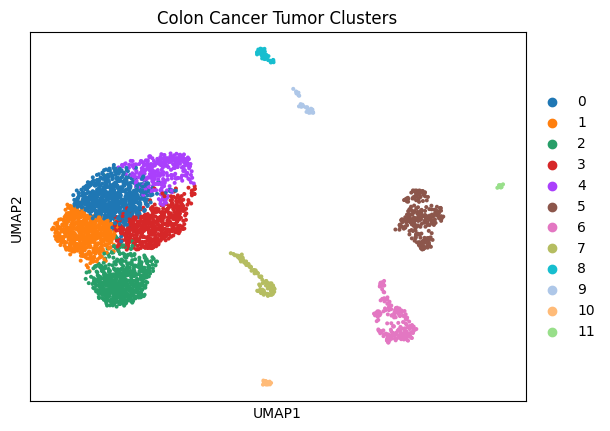

In [25]:
# 1. Run Principal Component Analysis (PCA)
# This reduces the 2000 genes down to 50 principal components that capture the most variance
sc.tl.pca(adata, svd_solver='arpack')

# 2. Compute the neighborhood graph of cells
# This looks at the PCA space and finds which cells are closest to each other mathematically
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)

# 3. Calculate the UMAP embedding
# This takes the complex graph and flattens it into a 2D map we can look at
sc.tl.umap(adata)

# 4. Cluster the cells using the Leiden algorithm
# This automatically draws boundaries around the cell groups based on the graph
sc.tl.leiden(adata, resolution=0.5)

# 5. Plot the final UMAP
sc.pl.umap(adata, color=['leiden'], title='Colon Cancer Tumor Clusters')

Re-calculating marker genes with gene symbols as var_names (delimiter='|')...


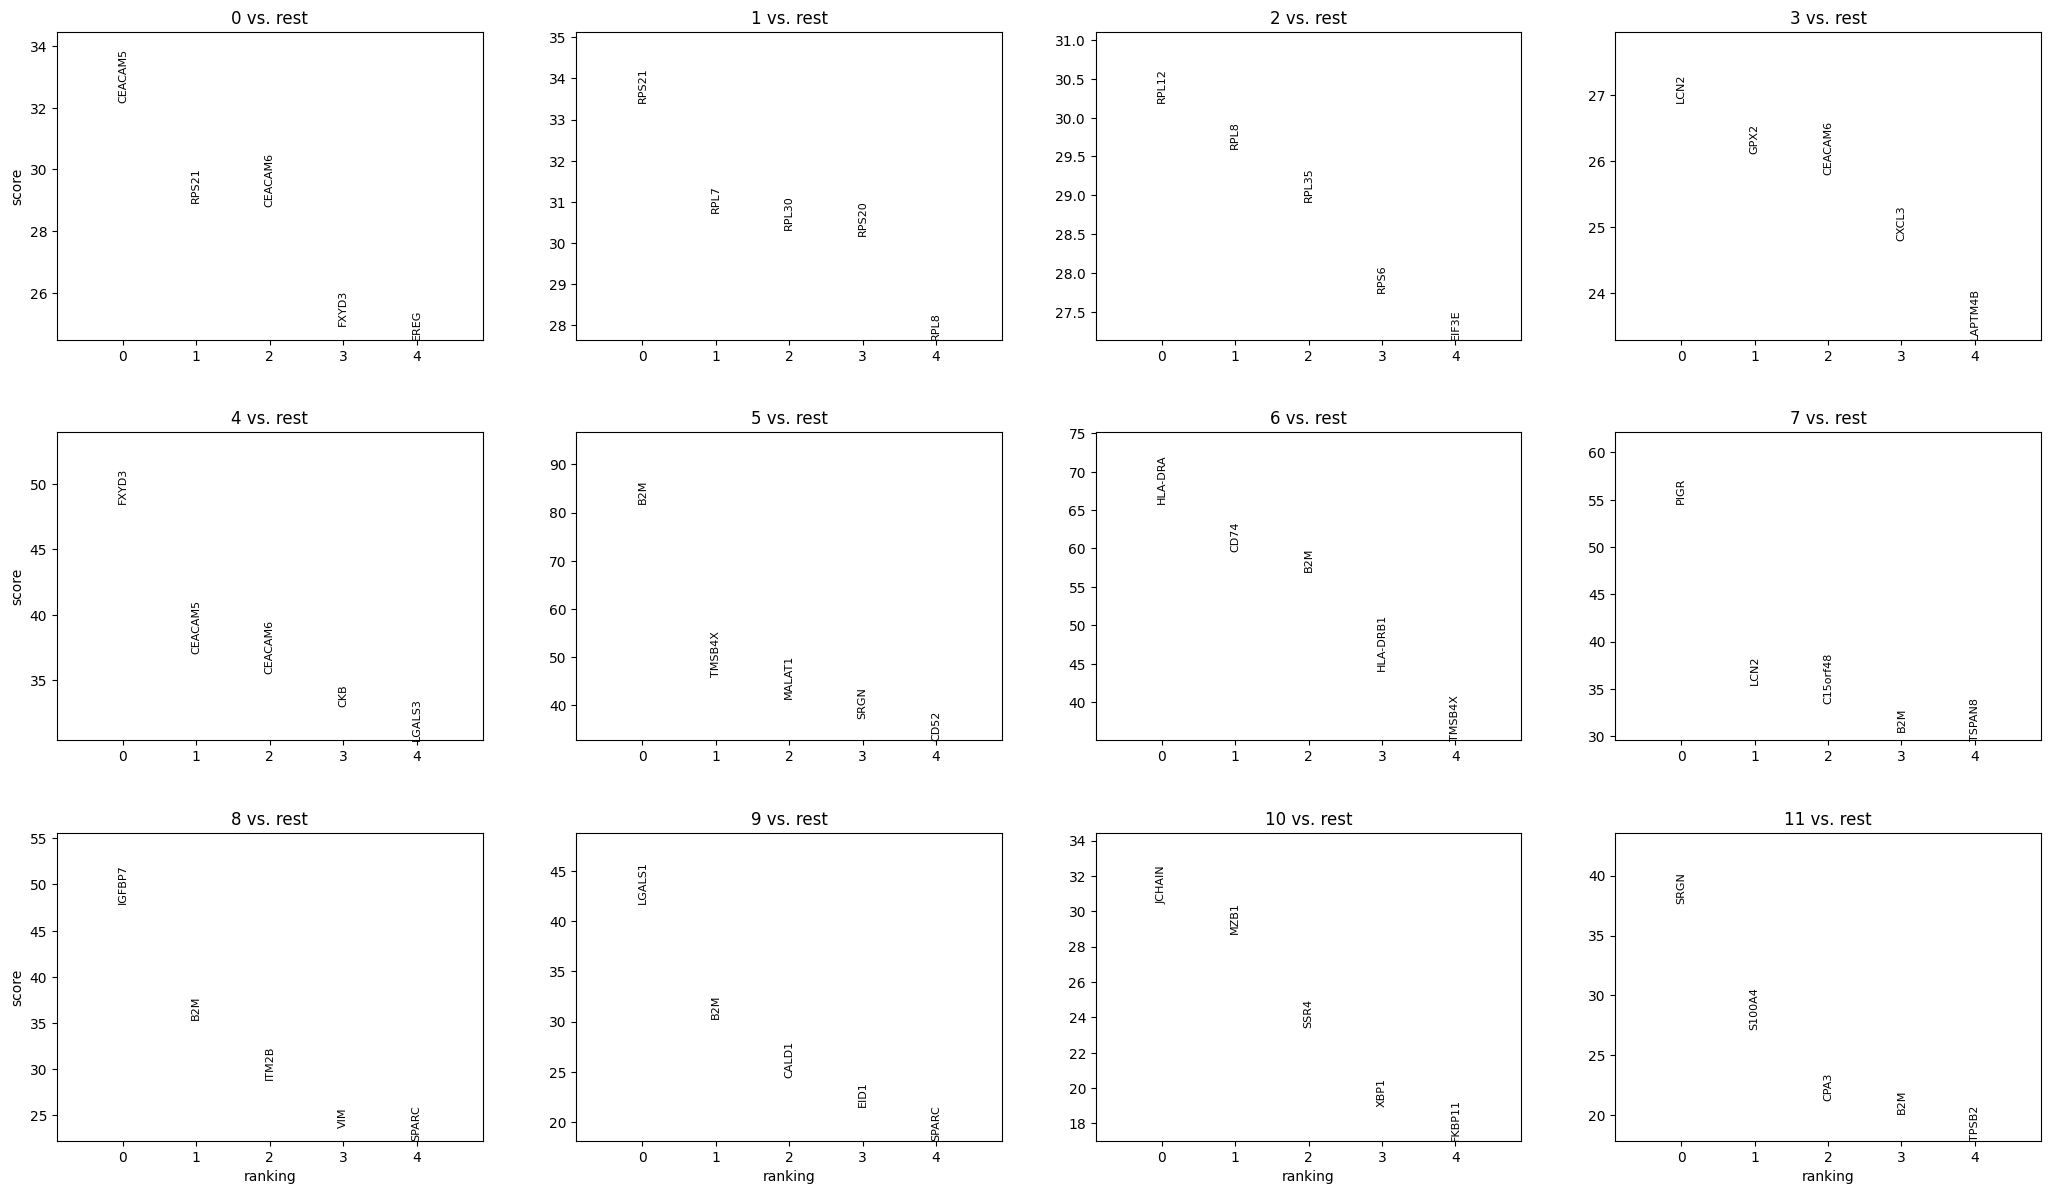

In [32]:
import pandas as pd

# create unique index helper
# Use '|' as delimiter to avoid colliding with common gene-name characters like '-'
def make_unique(names, sep='|'):
    seen = {}
    out = []
    for n in map(str, names):
        if n not in seen:
            seen[n] = 0
            out.append(n)
        else:
            seen[n] += 1
            out.append(f"{n}{sep}{seen[n]}")
    return pd.Index(out)

# Backup original feature IDs (non-destructive)
adata.var['orig_id'] = adata.var_names.astype(str)

# Replace adata.var_names with gene symbols (if not already)
ad_symbols = adata.var['feature_name'].astype(str)
if not adata.var_names.equals(ad_symbols):
    adata.var_names = ad_symbols
    # use '|' to suffix duplicates for clarity and safer parsing later
    adata.var_names_make_unique(join='|')

# Update adata.raw.var index safely (cannot assign adata.raw.var_names)
raw_backup = adata.raw.copy() if adata.raw is not None else None
if adata.raw is not None:
    new_raw_index = make_unique(adata.var['feature_name'].astype(str).values, sep='|')
    adata.raw.var.index = new_raw_index

# Clear any cached rank_genes_groups and recompute markers
if 'rank_genes_groups' in adata.uns:
    del adata.uns['rank_genes_groups']
print("Re-calculating marker genes with gene symbols as var_names (delimiter='|')...")
sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test')

# Plot the top markers
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False, title='Top Cluster Marker Genes')

# To save this AnnData (persist change to disk), optionally write:
# adata.write('colon_cancer_adata_symbols.h5ad')

# To revert to original numeric IDs later (if needed):
# if adata.raw is not None:
#     adata.raw = raw_backup
# adata.var_names = adata.var['orig_id'].astype(str)
# adata.var_names_make_unique(join='|')

categories: 0, 1, 2, etc.
var_group_labels: Epithelial/Tumor, T-Cells, B-Cells, etc.


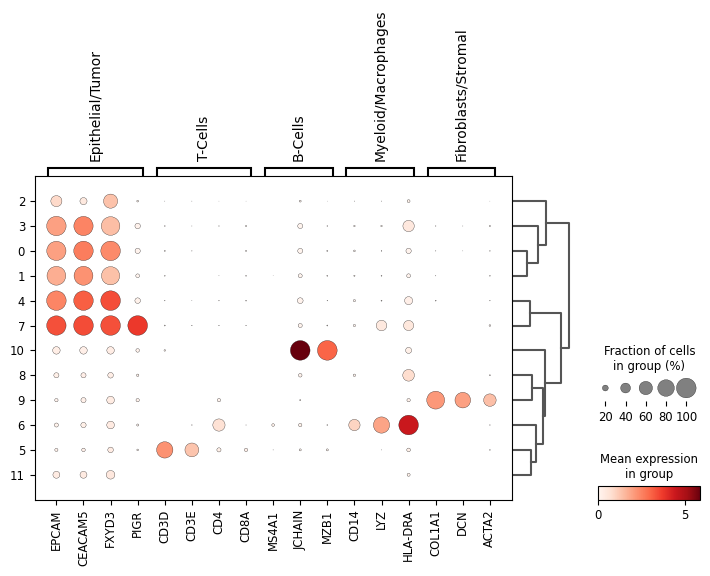

In [34]:
# A list of textbook marker genes for colon tumors
canonical_markers = {
    'Epithelial/Tumor': ['EPCAM', 'CEACAM5', 'FXYD3', 'PIGR'],
    'T-Cells': ['CD3D', 'CD3E', 'CD4', 'CD8A'],
    'B-Cells': ['MS4A1', 'JCHAIN', 'MZB1'],
    'Myeloid/Macrophages': ['CD14', 'LYZ', 'HLA-DRA'],
    'Fibroblasts/Stromal': ['COL1A1', 'DCN', 'ACTA2']
}

# Plot how these famous genes line up across your 12 clusters
sc.pl.dotplot(adata, canonical_markers, groupby='leiden', dendrogram=True)

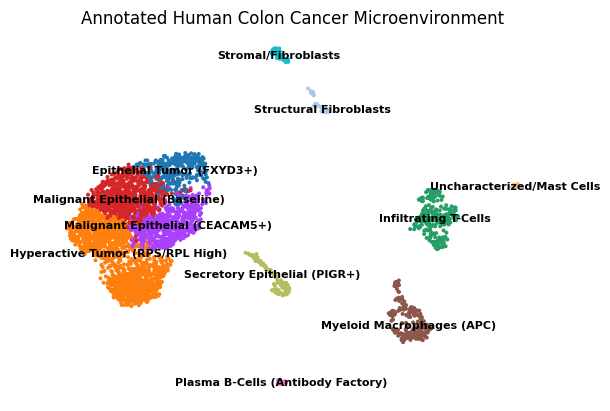

In [35]:
# 1. Map your custom names based on the combination of the dot plot and bar charts
cell_type_mapping = {
    '0': 'Malignant Epithelial (Baseline)',
    '1': 'Hyperactive Tumor (RPS/RPL High)',
    '2': 'Hyperactive Tumor (RPS/RPL High)',
    '3': 'Malignant Epithelial (CEACAM5+)',
    '4': 'Epithelial Tumor (FXYD3+)',
    '5': 'Infiltrating T-Cells',
    '6': 'Myeloid Macrophages (APC)',
    '7': 'Secretory Epithelial (PIGR+)',
    '8': 'Stromal/Fibroblasts',
    '9': 'Structural Fibroblasts',
    '10': 'Plasma B-Cells (Antibody Factory)',
    '11': 'Uncharacterized/Mast Cells'
}

# 2. Add these labels into your metadata table
adata.obs['cell_type_labeled'] = adata.obs['leiden'].map(cell_type_mapping)

# 3. Plot the final, beautifully annotated UMAP map!
sc.pl.umap(
    adata, 
    color='cell_type_labeled', 
    legend_loc='on data', 
    frameon=False, 
    title='Annotated Human Colon Cancer Microenvironment',
    legend_fontsize=8,
    legend_fontweight='bold'
)

Moving on to Target Discovery Differential Expression (DE)

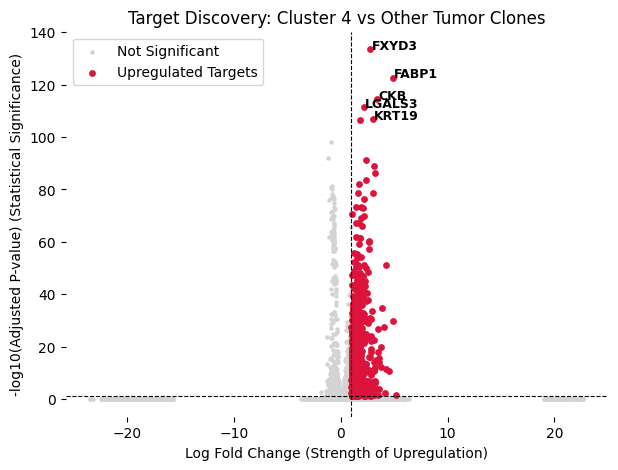

In [37]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Isolate only the epithelial/tumor clusters
tumor_clusters = ['0', '1', '2', '3', '4']
adata_tumor = adata[adata.obs['leiden'].isin(tumor_clusters)].copy()

# 2. Run the targeted DE test (Cluster 4 vs the other tumor clones)
sc.tl.rank_genes_groups(
    adata_tumor, 
    groupby='leiden', 
    groups=['4'], 
    reference='rest', 
    method='wilcoxon'
)

# 3. Extract the full statistical dataframe
result_df = sc.get.rank_genes_groups_df(adata_tumor, group='4')

# 4. Generate a clean, publication-ready Volcano Plot
plt.figure(figsize=(7, 5))

# Plot all background genes as small gray dots
plt.scatter(result_df['logfoldchanges'], -np.log10(result_df['pvals_adj'] + 1e-300), 
            color='lightgrey', s=5, label='Not Significant')

# Highlight significantly upregulated drug targets (LogFoldChange > 1, p-value < 0.05)
sig_up = (result_df['logfoldchanges'] > 1) & (result_df['pvals_adj'] < 0.05)
plt.scatter(result_df.loc[sig_up, 'logfoldchanges'], -np.log10(result_df.loc[sig_up, 'pvals_adj'] + 1e-300), 
            color='crimson', s=15, label='Upregulated Targets')

# Label the top 5 absolute standout target genes on the plot
top_targets = result_df.loc[sig_up].head(5)
for i, row in top_targets.iterrows():
    plt.text(row['logfoldchanges'] + 0.1, -np.log10(row['pvals_adj'] + 1e-300), 
             row['names'], fontsize=9, fontweight='bold')

# Clean up axes and add industrial styling
plt.axvline(x=1, color='black', linestyle='--', linewidth=0.8)
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Log Fold Change (Strength of Upregulation)')
plt.ylabel('-log10(Adjusted P-value) (Statistical Significance)')
plt.title('Target Discovery: Cluster 4 vs Other Tumor Clones')
plt.legend(loc='upper left')
plt.box(False) # Turn off the heavy border frame

plt.show()

Conclusion for this patient:
- FXYD3
- FABP1
- CKB
- LGALS3
- KRT19